# BLINK

BLINK: Multimodal Large Language Models Can See but Not Perceive

This notebook demonstrates how to load, inspect, and visualize the BLINK dataset, a benchmark designed to evaluate fine-grained visual perception and reasoning abilities in multimodal language models.

* Website: [https://zeyofu.github.io/blink/](https://zeyofu.github.io/blink/)
* GitHub: [https://github.com/zeyofu/BLINK](https://github.com/zeyofu/BLINK)
* Dataset: [https://huggingface.co/datasets/BLINK-Benchmark/BLINK](https://huggingface.co/datasets/BLINK-Benchmark/BLINK)

In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt

ds = load_dataset("BLINK-Benchmark/BLINK")

print(ds.keys())  # see available splits

for split in ds.keys():
    sample = ds[split][0]
    print("\n====", split, "====")
    print(sample.keys())

    # BLINK may have one or multiple images
    images = sample["image"] if isinstance(sample["image"], list) else [sample["image"]]

    for i, img in enumerate(images):
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{split} | image {i}")
        plt.show()

    print("Question:", sample.get("question"))
    print("Choices:", sample.get("choices"))
    print("Answer:", sample.get("answer"))

Generating test split: 100%|██████████| 136/136 [00:00<00:00, 1069.74 examples/s]
C:\Users\Masoud\AppData\Local\Temp\ipykernel_40744\2077596979.py:44: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


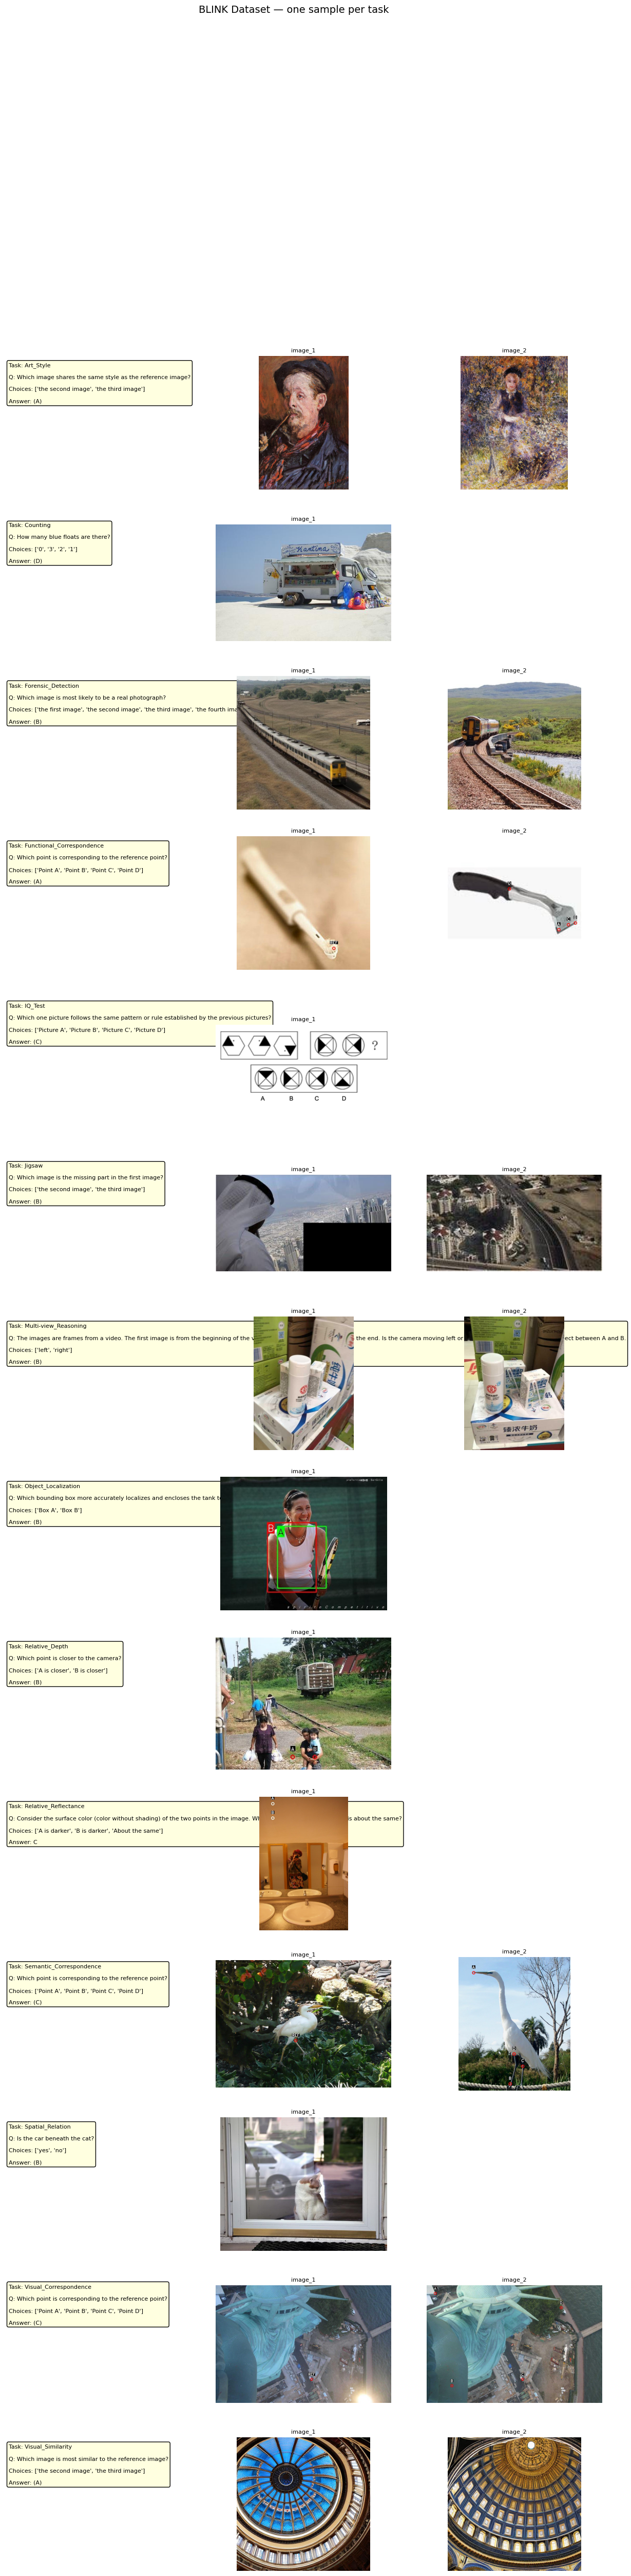

In [2]:
from datasets import load_dataset
import matplotlib.pyplot as plt

CONFIGS = [
    'Art_Style', 'Counting', 'Forensic_Detection', 'Functional_Correspondence',
    'IQ_Test', 'Jigsaw', 'Multi-view_Reasoning', 'Object_Localization',
    'Relative_Depth', 'Relative_Reflectance', 'Semantic_Correspondence',
    'Spatial_Relation', 'Visual_Correspondence', 'Visual_Similarity'
]

fig, axes = plt.subplots(len(CONFIGS), 3, figsize=(15, len(CONFIGS) * 4))

for row, config in enumerate(CONFIGS):
    ds = load_dataset("BLINK-Benchmark/BLINK", config, split="val")
    sample = ds[0]

    images = sample.get("image_1"), sample.get("image_2")
    images = [img for img in images if img is not None]
    if not images and sample.get("image"):
        images = sample["image"] if isinstance(sample["image"], list) else [sample["image"]]

    # Col 0: task info
    ax = axes[row, 0]
    ax.axis("off")
    q = sample.get("question", "")
    choices = sample.get("choices", [])
    ans = sample.get("answer", "")
    text = f"Task: {config}\n\nQ: {q}\n\nChoices: {choices}\n\nAnswer: {ans}"
    ax.text(0.02, 0.95, text, va="top", ha="left", wrap=True, fontsize=8,
            transform=ax.transAxes, bbox=dict(boxstyle="round", fc="lightyellow"))

    # Col 1 & 2: images
    for col_offset, img in enumerate(images[:2]):
        ax = axes[row, col_offset + 1]
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"image_{col_offset + 1}", fontsize=8)

    # blank unused image columns
    for col_offset in range(len(images[:2]), 2):
        axes[row, col_offset + 1].axis("off")

plt.suptitle("BLINK Dataset — one sample per task", fontsize=14, y=1.002)
plt.tight_layout()
plt.show()

## Dataset

This notebook uses **BLINK: Multimodal Large Language Models Can See but Not Perceive**, a benchmark containing 14 visual perception tasks that challenge multimodal language models on subtle visual reasoning problems.

Tasks include:

* counting
* spatial relations
* relative depth
* object localization
* visual correspondence
* visual similarity
* semantic correspondence
* and more.

**Dataset citation**

```bibtex
@inproceedings{fu2024blink,
  title={BLINK: Multimodal Large Language Models Can See but Not Perceive},
  author={Fu, Xingyu and Hu, Yushi and Li, Bangzheng and Feng, Yu and Wang, Haoyu and Lin, Xudong and Roth, Dan and others},
  booktitle={ECCV},
  year={2024}
}
```

Code for loading, inspecting, and visualizing the BLINK dataset was written by **Masoud Jafaripour** for analysis and VLM evaluation purposes.
This code is **not affiliated with the dataset authors**.